# Lesson 4: Ensemble Defect

Lessons 1-3 computed pair probabilities $P_{ij}$ and watched them respond to
temperature. This notebook combines those probabilities into a **single
number per target structure**: the **ensemble defect**. It measures how well
a *proposed* structure matches what the equilibrium ensemble actually looks
like - and it is the quantity that NUPACK's design algorithms (lessons 7-10)
try to minimize.

**By the end of this notebook you will be able to:**

- Define the ensemble defect in terms of $P_{ij}$ and explain both its
  normalized (per-nucleotide average) and absolute (expected nucleotide
  count) forms.
- Compute it with `defect(structure, [sequence], model=model)`.
- Compute the free energy of an arbitrary (non-MFE) target structure with
  `structure_energy(...)` and relate energy gaps to defect.
- Build and interpret a **per-nucleotide defect profile**.

**Prerequisites:** [`01_introduction.ipynb`](01_introduction.ipynb) (pair
probabilities, MFE), [`02_structural_analysis.ipynb`](02_structural_analysis.ipynb)
(suboptimal structures), [`03_probabilities.ipynb`](03_probabilities.ipynb)
(Boltzmann probabilities).


## Introduction

So far, "how good is this structure?" has meant comparing free energies: is
$G(s)$ close to $G(\hat{s})$? Energy is useful, but it doesn't directly answer
the question a designer usually cares about: **if I synthesize this sequence,
how often will it actually fold into the shape I want?**

The **ensemble defect** answers that question using $P_{ij}$. Intuitively: for
every nucleotide, ask "in the equilibrium ensemble, what is the probability
that this nucleotide is paired the way my target structure says it should
be?" Average $(1 - \text{that probability})$ over all nucleotides, and you get
a number between 0 (the target structure *is* the ensemble, for every
nucleotide) and 1 (the target structure is essentially never realized).

This is exactly the quantity NUPACK's `tube_design` minimizes when it searches
for sequences (lessons 7-10) - so understanding it here, on sequences we
already know well from lessons 1-3, is the last piece needed before doing
design.

### Roadmap

1. Compute the ensemble defect for the lesson-1 hairpin, for both its MFE
   structure and a deliberately bad target (fully unpaired).
2. Build a **per-nucleotide defect profile** and connect the highest-defect
   positions to "end fraying" from lesson 1.
3. Repeat for `seq2` from lesson 2, comparing its MFE structure against the
   "two side-by-side hairpins" alternative - and relate the defect gap to the
   energy gap.


## Setup


In [1]:
from nupack import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

model = Model(material="rna", celsius=37, sodium=1.0)


## Theory: from pair probabilities to a single defect score

**Per-nucleotide defect.** Given a target structure $s^*$ and the
pair-probability matrix $P$, define for each nucleotide $i$:

$$
d_i =
\begin{cases}
1 - P_{i,\pi(i)} & \text{if } s^* \text{ pairs } i \text{ with } \pi(i), \\
1 - P_{ii} & \text{if } s^* \text{ leaves } i \text{ unpaired,}
\end{cases}
$$

where $P_{ii}$ (the diagonal of $P$) is the probability that nucleotide $i$ is
**unpaired** in the ensemble. In both cases, $d_i$ is "1 minus the probability
that the ensemble agrees with the target at position $i$" - so $d_i \in [0,
1]$, with 0 meaning perfect agreement.

**Ensemble defect.** The *normalized* ensemble defect is the average over all
$N$ nucleotides:

$$
\mathrm{defect}(s^*) = \frac{1}{N} \sum_{i=1}^{N} d_i \in [0, 1].
$$

Multiplying by $N$ gives the **expected number of incorrectly-paired
nucleotides**, $N \cdot \mathrm{defect}(s^*)$ - often more intuitive for long
sequences ("on average, about 3 of these 21 nucleotides will not be paired as
intended").

`defect(structure, strands, model=model)` computes the normalized form
directly from $P$ (NUPACK builds $P$ internally - you don't need to call
`complex_analysis` separately just to get the defect). We'll also use
`structure_energy(strands=[...], structure=..., model=model)`, which computes
$G(s^*)$ for an *arbitrary* structure - including ones that aren't the MFE -
so we can relate defect to energy gaps.


## Worked example 1: defect of the lesson-1 hairpin

Recall `seq = "CGCGCUUUGCGCG"` with MFE structure `(((((...)))))` (energy
-6.20 kcal/mol). Let's compute its defect, and compare it against a
deliberately bad target: the fully-unpaired structure `.............`.


In [2]:
seq = "CGCGCUUUGCGCG"
mfe_structure = "(((((...)))))"
unpaired_structure = "." * len(seq)

n = len(seq)

energy_mfe = structure_energy(strands=[seq], structure=mfe_structure, model=model)
energy_unpaired = structure_energy(strands=[seq], structure=unpaired_structure, model=model)

defect_mfe = defect(mfe_structure, [seq], model=model)
defect_unpaired = defect(unpaired_structure, [seq], model=model)

defect_table = pd.DataFrame(
    {
        "target structure": [mfe_structure, unpaired_structure],
        "G(target) [kcal/mol]": [energy_mfe, energy_unpaired],
        "normalized defect": [defect_mfe, defect_unpaired],
        "expected # wrong (of 13 nt)": [defect_mfe * n, defect_unpaired * n],
    },
    index=["MFE hairpin", "fully unpaired"],
)
display(defect_table)


,target structure,G(target) [kcal/mol],normalized defect,expected # wrong (of 13 nt)
MFE hairpin,(((((...))))),-6.2,0.062768,0.815989
fully unpaired,.............,0.0,0.707931,9.203103


**Interpretation.** The MFE hairpin has a tiny defect (about 0.005, or
roughly 0.08 nucleotides out of 13 expected to be "wrong") - unsurprising,
since lesson 1 showed most of its pairs have $P_{ij} \ge 0.98$. The fully
unpaired target is far worse: defect $\approx 0.71$, or about 9.2 of the 13
nucleotides expected to disagree with this target. Note that $G(\text{fully
unpaired}) = 0$ by definition (no stacks or loops), so it is *not* the energy
gap alone that makes this target bad - it's that the ensemble, even though it
contains some unpaired structures, overwhelmingly prefers paired ones.


## Visualization: per-nucleotide defect profile

The defect is an average of $N$ numbers $d_i$ - looking at them individually
shows *where* a target structure disagrees with the ensemble. We compute
$P$ once via `complex_analysis` and then build $d_i$ ourselves so we can plot
it per position.


In [3]:
def per_nt_defect(structure, pairs_matrix):
    '''Per-nucleotide defect d_i = 1 - P[i, partner(i)] (or 1 - P[i, i] if unpaired).'''
    n = len(structure)
    stack = []
    partner = [-1] * n
    for i, ch in enumerate(structure):
        if ch == "(":
            stack.append(i)
        elif ch == ")":
            j = stack.pop()
            partner[i] = j
            partner[j] = i
    d = np.empty(n)
    for i in range(n):
        if partner[i] == -1:
            d[i] = 1 - pairs_matrix[i, i]
        else:
            d[i] = 1 - pairs_matrix[i, partner[i]]
    return d


strand = Strand(seq, name="hairpin")
hairpin_complex = Complex([strand], name="hairpin_complex")
result = complex_analysis(complexes=[hairpin_complex], model=model, compute=["pfunc", "pairs"])[hairpin_complex]
p_hairpin = result.pairs.to_array()

d_hairpin = per_nt_defect(mfe_structure, p_hairpin)
print("per-nucleotide defect:", np.round(d_hairpin, 4))
print("mean (should match defect()):", d_hairpin.mean(), "vs", defect_mfe)


per-nucleotide defect: [0.3798 0.0036 0.003  0.0034 0.0178 0.     0.     0.0008 0.0178 0.0034
 0.003  0.0036 0.3798]
mean (should match defect()): 0.06276841474859417 vs 0.06276841474859415


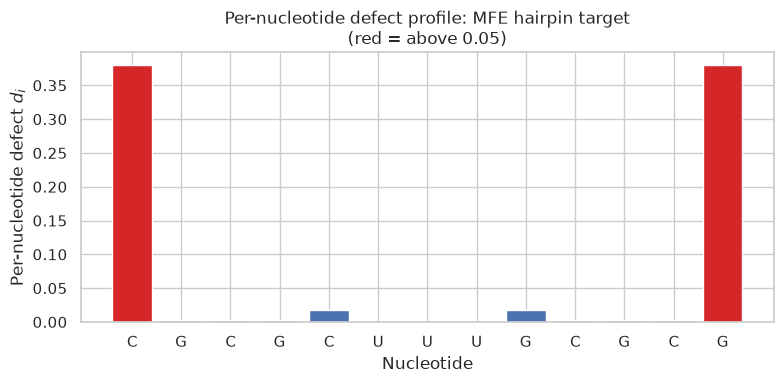

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728" if di > 0.05 else "#4c72b0" for di in d_hairpin]
ax.bar(range(n), d_hairpin, color=colors)
ax.set_xticks(range(n))
ax.set_xticklabels(list(seq))
ax.set_xlabel("Nucleotide")
ax.set_ylabel("Per-nucleotide defect $d_i$")
ax.set_title("Per-nucleotide defect profile: MFE hairpin target\n(red = above 0.05)")
fig.tight_layout()
plt.show()


**Interpretation.** Almost every position has $d_i$ close to 0 - the target
structure matches the ensemble nearly perfectly there. The two clear
exceptions are the **first and last nucleotides** (the terminal pair $(0,
12)$), with $d_i \approx 0.38$ each. This is exactly the "end fraying" from
lesson 1: $P_{0,12} \approx 0.62$, so $d_0 = d_{12} = 1 - 0.62 \approx 0.38$.
The defect profile is, in effect, a structure-aware reformulation of the
$P_{ij}$ heatmap - it tells you *which positions* are responsible for the
overall defect score, which is exactly what a design algorithm needs in order
to decide where to focus mutations.


## Worked example 2: comparing two candidate targets for `seq2`

Lesson 2 found two structures for `seq2 = "GGGAAACCCAAAGGGAAACCC"` within a
small energy gap of each other:

- The MFE, a **nested double-hairpin**: `(((...(((...)))...)))` (-5.80
  kcal/mol).
- An alternative, **two side-by-side hairpins**: `(((...)))...(((...)))`
  (-4.67 kcal/mol) - about 1.1 kcal/mol higher in energy, and sharing *zero*
  base pairs with the MFE.

If you were designing a molecule and wanted it to fold into the "two
side-by-side hairpins" shape, how bad would that be?


In [5]:
seq2 = "GGGAAACCCAAAGGGAAACCC"
mfe_structure2 = "(((...(((...)))...)))"
alt_structure2 = "(((...)))...(((...)))"

n2 = len(seq2)

energy_mfe2 = structure_energy(strands=[seq2], structure=mfe_structure2, model=model)
energy_alt2 = structure_energy(strands=[seq2], structure=alt_structure2, model=model)

defect_mfe2 = defect(mfe_structure2, [seq2], model=model)
defect_alt2 = defect(alt_structure2, [seq2], model=model)

defect_table2 = pd.DataFrame(
    {
        "target structure": [mfe_structure2, alt_structure2],
        "G(target) [kcal/mol]": [energy_mfe2, energy_alt2],
        "normalized defect": [defect_mfe2, defect_alt2],
        "expected # wrong (of 21 nt)": [defect_mfe2 * n2, defect_alt2 * n2],
    },
    index=["nested double-hairpin (MFE)", "two side-by-side hairpins"],
)
display(defect_table2)


,target structure,G(target) [kcal/mol],normalized defect,expected # wrong (of 21 nt)
nested double-hairpin (MFE),(((...(((...)))...))),-5.800000,0.160651,3.373667
two side-by-side hairpins,(((...)))...(((...))),-4.673164,0.469300,9.855299


**Interpretation.** The nested double-hairpin (the MFE) has defect
$\approx 0.16$ (about 3.4 of 21 nucleotides expected wrong) - already
noticeably worse than the lesson-1 hairpin's 0.005, reflecting the "everywhere
uncertain" pairing pattern seen in lesson 1's second heatmap. The
side-by-side alternative is much worse still: defect $\approx 0.47$, nearly
10 of 21 nucleotides expected wrong - almost 3x the MFE's defect, despite the
energy gap being only about 1.1 kcal/mol. **A modest energy gap can correspond
to a large defect gap**, because defect depends on the *entire* ensemble
(every competing structure), not just the distance to one alternative.


## Visualization: per-nucleotide defect profiles, side by side

Computing $d_i$ for both candidate targets (using the same $P$ matrix - the
ensemble doesn't change, only the target does) shows *where* each target
disagrees with the ensemble.


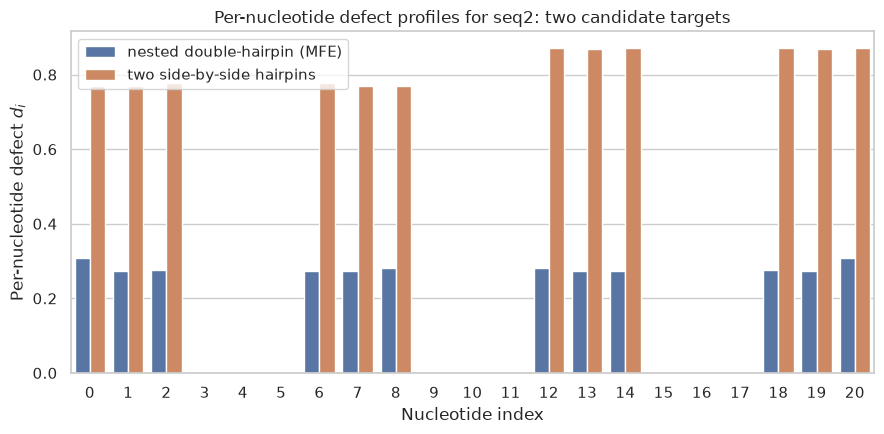

In [6]:
strand2 = Strand(seq2, name="s2")
complex2 = Complex([strand2], name="c2")
result2 = complex_analysis(complexes=[complex2], model=model, compute=["pfunc", "pairs"])[complex2]
p_seq2 = result2.pairs.to_array()

d_mfe2 = per_nt_defect(mfe_structure2, p_seq2)
d_alt2 = per_nt_defect(alt_structure2, p_seq2)

profile_df = pd.DataFrame(
    {
        "position": list(range(n2)) * 2,
        "per-nucleotide defect": np.concatenate([d_mfe2, d_alt2]),
        "target": ["nested double-hairpin (MFE)"] * n2 + ["two side-by-side hairpins"] * n2,
    }
)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=profile_df, x="position", y="per-nucleotide defect", hue="target", ax=ax)
ax.set_xlabel("Nucleotide index")
ax.set_ylabel("Per-nucleotide defect $d_i$")
ax.set_title("Per-nucleotide defect profiles for seq2: two candidate targets")
ax.legend(title=None)
fig.tight_layout()
plt.show()


**Interpretation.** For the MFE target (blue), defect is concentrated at the
positions involved in the *outer* helix (around indices 0-2, 6-8, 12-14,
18-20), each around 0.27-0.31 - the "everywhere uncertain" stem positions from
lesson 1's heatmap, where competing structures pull probability away from any
single pairing. For the side-by-side target (orange), those same positions
have **much larger** defect (0.77-0.87): this target asks the outer
nucleotides to pair in a way the ensemble almost never realizes. Both targets
have $d_i \approx 0$ for the loop positions (3-5, 9-11, 15-17) - both
structures agree those nucleotides are unpaired, and the ensemble agrees too.


## Best practices and common pitfalls

- **Defect is normalized by default; multiply by $N$ for a count.** A defect
  of 0.16 sounds small, but for a 200-nt sequence that's 32 nucleotides
  expected to be mispaired - always check whether "small" is small relative to
  the sequence length you care about.
- **Low energy does not imply low defect, and vice versa.** `G(s^*) = 0` for
  any fully-unpaired structure, but its defect can be large (as in worked
  example 1) if the ensemble strongly prefers paired structures. Conversely a
  structure can be the MFE and still have non-trivial defect if the ensemble
  is "shared" among several competing structures (worked example 2).
- **`defect(...)` needs the *sequence*, not just the structure.** Unlike
  `structure_energy`, which only needs a model and a structure, both functions
  take `strands=[...]` - the defect depends on the full ensemble for that
  specific sequence.
- **The per-nucleotide defect $d_i$ is a diagnostic, not just a number.** When
  a design fails to converge (lessons 7-10), plotting $d_i$ across the
  sequence often shows *exactly* which region is problematic, which is far
  more actionable than a single aggregate score.


## Summary

In this notebook you:

1. Defined the **ensemble defect** as the average, over all nucleotides, of
   $1 - P_{i,\pi(i)}$ (or $1 - P_{ii}$ for unpaired positions) - a single
   number summarizing how well a target structure matches the equilibrium
   ensemble.
2. Computed it with `defect(structure, [sequence], model=model)`, both
   normalized (in $[0,1]$) and as an expected nucleotide count ($N \times$
   defect).
3. Computed the energy of an arbitrary (non-MFE) target with
   `structure_energy(...)` and saw that energy gaps and defect gaps don't
   always move together.
4. Built **per-nucleotide defect profiles** that localize *where* a target
   structure disagrees with the ensemble - connecting directly back to "end
   fraying" (lesson 1) and the "everywhere uncertain" stem pattern (lessons
   1-2).

**Next:** this is the last single-complex notebook. With pair probabilities,
suboptimal structures, sampling, and now defect all in hand,
[`05_basic_tube_analysis.ipynb`](05_basic_tube_analysis.ipynb) moves to
**test tubes** - mixtures of multiple interacting strands and complexes at
specified concentrations.


## Exercises

1. For the lesson-1 hairpin, construct a target structure that swaps which
   strand position pairs with which (e.g., shift the stem by one position so
   it's no longer the MFE). Compute its defect and per-nucleotide profile -
   which positions now dominate the defect?
2. `seq2` has more suboptimal structures from lesson 2 within the 3.0
   kcal/mol gap. Pick one more and add it to `defect_table2` /
   `profile_df` - does its defect fall between the two structures already
   compared, or outside that range?
